In [1]:
# %pip install pandas pyarrow
import pandas as pd
import pyarrow.parquet as pq

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare PCA input

In [2]:
def prepare_stablecoin_pca_df(df):

    drop_cols = [
        'depeg', 'timeOpen', 'timeClose', 'timeHigh', 'timeLow',
        'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply',
        'depeg_future_1d', 'depeg_future_3d', 'depeg_future_5d', 'depeg_future_7d', 
        'depeg_future_14d', 'depeg_future_30d'
    ]

    pca_df = df.copy()

    # Drop only columns that actually exist
    pca_df = pca_df.drop(columns=[c for c in drop_cols if c in pca_df.columns], errors="ignore")
    
    pca_df['timestamp'] = pd.to_datetime(pca_df['timestamp']).dt.normalize()
    # Keep only timestamp, symbol and numeric feature columns
    pca_df = pca_df[['timestamp', 'symbol'] + [c for c in pca_df.columns if c not in ['timestamp', 'symbol'] and pd.api.types.is_numeric_dtype(pca_df[c])]]

    # Sort by time
    pca_df = pca_df.sort_values('timestamp').reset_index(drop=True)
    
    return pca_df

In [3]:
# df_dai_final = pd.read_parquet("../clean_data/dai_final.parquet")
# df_dai_pca = prepare_stablecoin_pca_df(df_dai_final)
# df_dai_pca.columns

# 2. Expanding PCA + PC Score Plots

In [4]:
def expanding_pca_scores(df, min_window=30, n_components=10, plot_pc=None):
    # Copy data
    pca_df = df.copy().reset_index(drop=True)

    # Keep numeric feature columns only, excluding timestamp and symbol
    feature_cols = [c for c in pca_df.columns if c not in ['timestamp', 'symbol']]
    X = pca_df[feature_cols].select_dtypes(include=[np.number]).copy()

    # Keep only rows with complete numeric data
    valid_mask = X.notna().all(axis=1)
    X = X.loc[valid_mask].reset_index(drop=True)
    pca_df = pca_df.loc[valid_mask].reset_index(drop=True)

    if X.shape[1] == 0:
        raise ValueError("No numeric indicator columns remain after preprocessing.")

    pc_scores_list = []
    loadings_dict = {}

    for i in range(min_window - 1, len(X)):
        # Expanding window: from start up to current time i
        window_X = X.iloc[: i + 1].copy()

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(window_X)

        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X_scaled)

        # Last-day PC coordinates in this expanding window
        last_day_scores = X_pca[-1]

        row = {'timestamp': pca_df.loc[i, 'timestamp']}
        for j in range(n_components):
            row[f'PC{j+1}'] = last_day_scores[j]

        pc_scores_list.append(row)

        # Store loadings for this expanding window's PCA
        loadings = pd.DataFrame(
            pca.components_.T,
            index=feature_cols,
            columns=[f'PC{j+1}' for j in range(n_components)]
        )
        loadings_dict[pca_df.loc[i, 'timestamp']] = loadings

    pc_scores_df = pd.DataFrame(pc_scores_list)
    pc_scores_df['symbol'] = pca_df['symbol'].iloc[0]

    # Plot PC scores separately
    if plot_pc is True:
        fig, axes = plt.subplots(n_components, 1, figsize=(15, 2.5 * n_components), sharex=True)
        if n_components == 1:
            axes = [axes]

        for j in range(n_components):
            col = f'PC{j+1}'
            axes[j].plot(pc_scores_df['timestamp'], pc_scores_df[col], linewidth=1.2)
            axes[j].axhline(0, linestyle=':', linewidth=1)
            axes[j].set_ylabel(col, fontsize=16)

        axes[0].set_title(
            f"Expanding-window PCA scores (min_window={min_window}, last-day coordinates) for {pca_df['symbol'].iloc[0]}",
            fontsize=20
        )
        axes[-1].set_xlabel("Date")
        plt.tight_layout()
        plt.show()

    return pc_scores_df, loadings_dict

# 3. Z-socre band
- Symmetric threshold band ±m

In [5]:
from matplotlib.pyplot import plot


def plot_pc_zscore_bands(pc_scores_df, pc_cols=None, m = 2.0, baseline_end=None, 
                         hit_df=None, depeg_df=None, window=60, plot_pc = None):
    pc_scores_df = pc_scores_df.copy()
    pc_scores_df['timestamp'] = pd.to_datetime(pc_scores_df['timestamp']).dt.normalize()
    baseline_end = pd.to_datetime(baseline_end).normalize()
    
    fig = None

    # fixed baseline
    baseline_mask = pc_scores_df["timestamp"] <= baseline_end

    if baseline_mask.sum() == 0:
        raise ValueError("No baseline observations found before baseline_end.")

    z_df = pc_scores_df[["timestamp"]].copy()

    for col in pc_cols:
        base = pc_scores_df.loc[baseline_mask, col].dropna()
        mu = base.mean()
        sd = base.std(ddof=1)

        if pd.isna(sd) or sd == 0:
            z_df[col] = np.nan
        else:
            z_df[col] = (pc_scores_df[col] - mu) / sd
    
    z_df['symbol'] = pc_scores_df['symbol'].iloc[0]
    
    if plot_pc == True:
        fig, axes = plt.subplots(len(pc_cols), 1, figsize=(15, 2.5 * len(pc_cols)), sharex=True)
        if len(pc_cols) == 1:
            axes = [axes]

        for i, col in enumerate(pc_cols):
            ax = axes[i]
            ymin, ymax = ax.get_ylim()
            ax.set_yticks(np.arange(ymin-10, ymax+10, 1))
            ax.set_ylabel(col, fontsize=16)
            

            ax.plot(z_df["timestamp"], z_df[col], linewidth=1.2)

            # bands
            ax.axhline(+m, linestyle="--", linewidth=1)
            ax.axhline(-m, linestyle="--", linewidth=1)
            ax.axhline(0, linestyle=":", linewidth=1)

            # optional: highlight hits
            if hit_df is not None and not hit_df.empty:
                pc_hits = hit_df[hit_df["PC"] == col]
                if not pc_hits.empty:
                    hit_dates = pd.to_datetime(pc_hits["hit_date"])
                    hit_vals = z_df.loc[z_df["timestamp"].isin(hit_dates), ["timestamp", col]]
                    ax.scatter(hit_vals["timestamp"], hit_vals[col], s=30)

            ax.set_ylabel(col)
            
            # overlay true depeg days
            if depeg_df is not None and not depeg_df.empty:
                depeg_dates = pd.to_datetime(depeg_df["timestamp"])
                depeg_vals = z_df.loc[z_df["timestamp"].isin(depeg_dates), ["timestamp", col]]
                ax.scatter(depeg_vals["timestamp"], depeg_vals[col], marker="x", s=50, zorder=5)
                

        axes[0].set_title(f"Expanding-window z-scores (min_window=30, last-day coordinates) with ±{m}σ bands for {pc_scores_df['symbol'].iloc[0]}",
                        fontsize = 20)
        axes[-1].set_xlabel("Date")
        
        plt.tight_layout()
        plt.show()
    

    return z_df, fig

In [6]:
# z_df_dai = plot_pc_zscore_bands(pc_scores_dai, baseline_end="2026-03-19", m = 3.0,
#                      pc_cols=[f"PC{i}" for i in range(1, 11)], window=60)

# 4. Warnings vs Real Depegs

In [7]:
def get_pc_hits(
    z_df,
    m,
    original_df,
    depeg_df,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=True # True: same-day hit counts, False: must give at least 1-day warning
):
    z_df = z_df.copy()
    z_df["timestamp"] = pd.to_datetime(z_df["timestamp"]).dt.normalize()

    original_df = original_df.copy()
    original_df["timestamp"] = pd.to_datetime(original_df["timestamp"]).dt.normalize()

    depeg_df = depeg_df.copy()
    depeg_df["timestamp"] = pd.to_datetime(depeg_df["timestamp"]).dt.normalize()

    depeg_dates = sorted(depeg_df["timestamp"].drop_duplicates())

    close_df = (
        original_df[["timestamp", "close"]]
        .drop_duplicates(subset="timestamp")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    hit_records = []

    for col in pc_cols:
        temp = z_df[["timestamp", col]].copy()
        temp = temp.rename(columns={col: "z_score"})

        hit_days_df = temp[temp["z_score"].abs() > m].copy()

        if hit_days_df.empty:
            continue

        hit_days_df["PC"] = col

        # merge close
        hit_days_df = hit_days_df.merge(close_df, on="timestamp", how="left")
        hit_days_df = hit_days_df.rename(columns={
            "timestamp": "hit_date",
            "close": "close_price"
        })

        matched_depeg_dates = []
        lead_times = []
        is_matched_list = []

        for hit_date in hit_days_df["hit_date"]:
            if include_no_lead_time:
                valid_depegs = [
                    d for d in depeg_dates
                    if hit_date <= d and (d - hit_date).days <= max_lead_days
                ]
            else:
                valid_depegs = [
                    d for d in depeg_dates
                    if hit_date < d and 1 <= (d - hit_date).days <= max_lead_days
                ]

            if valid_depegs:
                nearest = min(valid_depegs)
                matched_depeg_dates.append(nearest)
                lead_times.append((nearest - hit_date).days)
                is_matched_list.append(True)
            else:
                matched_depeg_dates.append(pd.NaT)
                lead_times.append(np.nan)
                is_matched_list.append(False)

        hit_days_df["matched_depeg_date"] = matched_depeg_dates
        hit_days_df["lead_time_days"] = lead_times
        hit_days_df["is_matched"] = is_matched_list

        hit_records.append(hit_days_df)

    if len(hit_records) == 0:
        return pd.DataFrame(columns=[
            "hit_date", "z_score", "PC", "close_price",
            "matched_depeg_date", "lead_time_days", "is_matched"
        ])

    hit_df = (
        pd.concat(hit_records, ignore_index=True)
        .sort_values(["PC", "hit_date"])
        .reset_index(drop=True)
    )

    return hit_df

In [8]:
def get_real_depeg_days(df_final: pd.DataFrame):

    df = df_final.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.normalize()

    if "depeg" not in df.columns:
        raise ValueError("Column 'depeg' not found in dataframe.")

    depeg_df = (
        df[df["depeg"] == 1][["timestamp"]]
        .drop_duplicates()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return depeg_df

In [9]:
# depeg_df_dai = get_real_depeg_days(df_dai_final)
# hit_df_dai = get_pc_hits(
#     z_df=z_df_dai,
#     m=2,
#     original_df=df_dai_final,
#     depeg_df=depeg_df_dai,
#     include_no_lead_time=True
# )

# plot_pc_zscore_bands(
#     z_df_dai,
#     m = 3.0,
#     baseline_end="2026-03-19",
#     pc_cols=[f"PC{i}" for i in range(1, 11)],
#     hit_df=hit_df_dai,
#     depeg_df=depeg_df_dai
# )

# 5. Evaluation

In [10]:
def summarize_pc_hits(
    hit_df,
    z_df,
    depeg_df,
    pc_cols,
    max_lead_days=7,
    include_no_lead_time=True
):
    z_df = z_df.copy()
    z_df["timestamp"] = pd.to_datetime(z_df["timestamp"]).dt.normalize()

    depeg_df = depeg_df.copy()
    depeg_df["timestamp"] = pd.to_datetime(depeg_df["timestamp"]).dt.normalize()

    hit_df = hit_df.copy()
    hit_df["hit_date"] = pd.to_datetime(hit_df["hit_date"]).dt.normalize()
    hit_df["matched_depeg_date"] = pd.to_datetime(hit_df["matched_depeg_date"]).dt.normalize()

    depeg_dates = sorted(depeg_df["timestamp"].drop_duplicates())
    depeg_set = set(depeg_dates)

    all_dates = set(z_df["timestamp"].drop_duplicates())
    non_depeg_dates = all_dates - depeg_set

    summary_rows = []

    for pc in pc_cols:
        pc_hits = hit_df[hit_df["PC"] == pc].copy()
        hit_dates = set(pc_hits["hit_date"])

        matched_hits = pc_hits[pc_hits["is_matched"]].copy()

        if not matched_hits.empty:
            matched_hits["lead_time"] = (
                matched_hits["matched_depeg_date"] - matched_hits["hit_date"]
            ).dt.days

            if include_no_lead_time:
                matched_hits = matched_hits[
                    (matched_hits["lead_time"] >= 0) &
                    (matched_hits["lead_time"] <= max_lead_days)
                ]
            else:
                matched_hits = matched_hits[
                    (matched_hits["lead_time"] >= 1) &
                    (matched_hits["lead_time"] <= max_lead_days)
                ]

        if not matched_hits.empty:
            # earliest warning day for each matched depeg date
            earliest_hits = (
                matched_hits
                .sort_values("hit_date")
                .groupby("matched_depeg_date", as_index=False)
                .first()
            )

            avg_lead_time_matched = earliest_hits["lead_time"].mean()
            first_match_days = earliest_hits["hit_date"].sort_values().tolist()
            matched_depeg_days = earliest_hits["matched_depeg_date"].sort_values().tolist()
            matched_hit_dates = set(matched_hits["hit_date"])
        else:
            avg_lead_time_matched = np.nan
            first_match_days = []
            matched_depeg_days = []
            matched_hit_dates = set()

        covered_depeg_days = set()
        for d in depeg_dates:
            if include_no_lead_time:
                valid_hits = [h for h in hit_dates if h <= d and (d - h).days <= max_lead_days]
            else:
                valid_hits = [h for h in hit_dates if h < d and 1 <= (d - h).days <= max_lead_days]

            if valid_hits:
                covered_depeg_days.add(d)

        tp = len(matched_hit_dates)
        fp = len(hit_dates - matched_hit_dates)
        fn = len(depeg_set - covered_depeg_days)
        tn = len(non_depeg_dates - hit_dates)

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = (
            2 * precision * recall / (precision + recall)
            if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0
            else np.nan
        )
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        summary_rows.append({
            "PC": pc,
            "num_hit_days": len(hit_dates),
            "num_real_depeg_days": len(depeg_set),
            "num_matched_days": len(matched_hit_dates),
            "matched_depeg_days": matched_depeg_days,
            "first_match_days": first_match_days,
            "avg_close_price_hit_days": pc_hits["close_price"].mean() if not pc_hits.empty else np.nan,
            "avg_lead_time_matched": avg_lead_time_matched,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "specificity": specificity
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values(["num_matched_days", "precision"], ascending=False)
        .reset_index(drop=True)
    )

    return summary_df

In [11]:
# summary_df_dai = summarize_pc_hits(
#     hit_df=hit_df_dai,
#     z_df=z_df_dai,
#     depeg_df=depeg_df_dai,
#     pc_cols=[f"PC{i}" for i in range(1, 11)],
#     max_lead_days=7,
#     include_no_lead_time=False
# )

In [12]:
# summary_df_dai.head(10)

# Example Call DAI

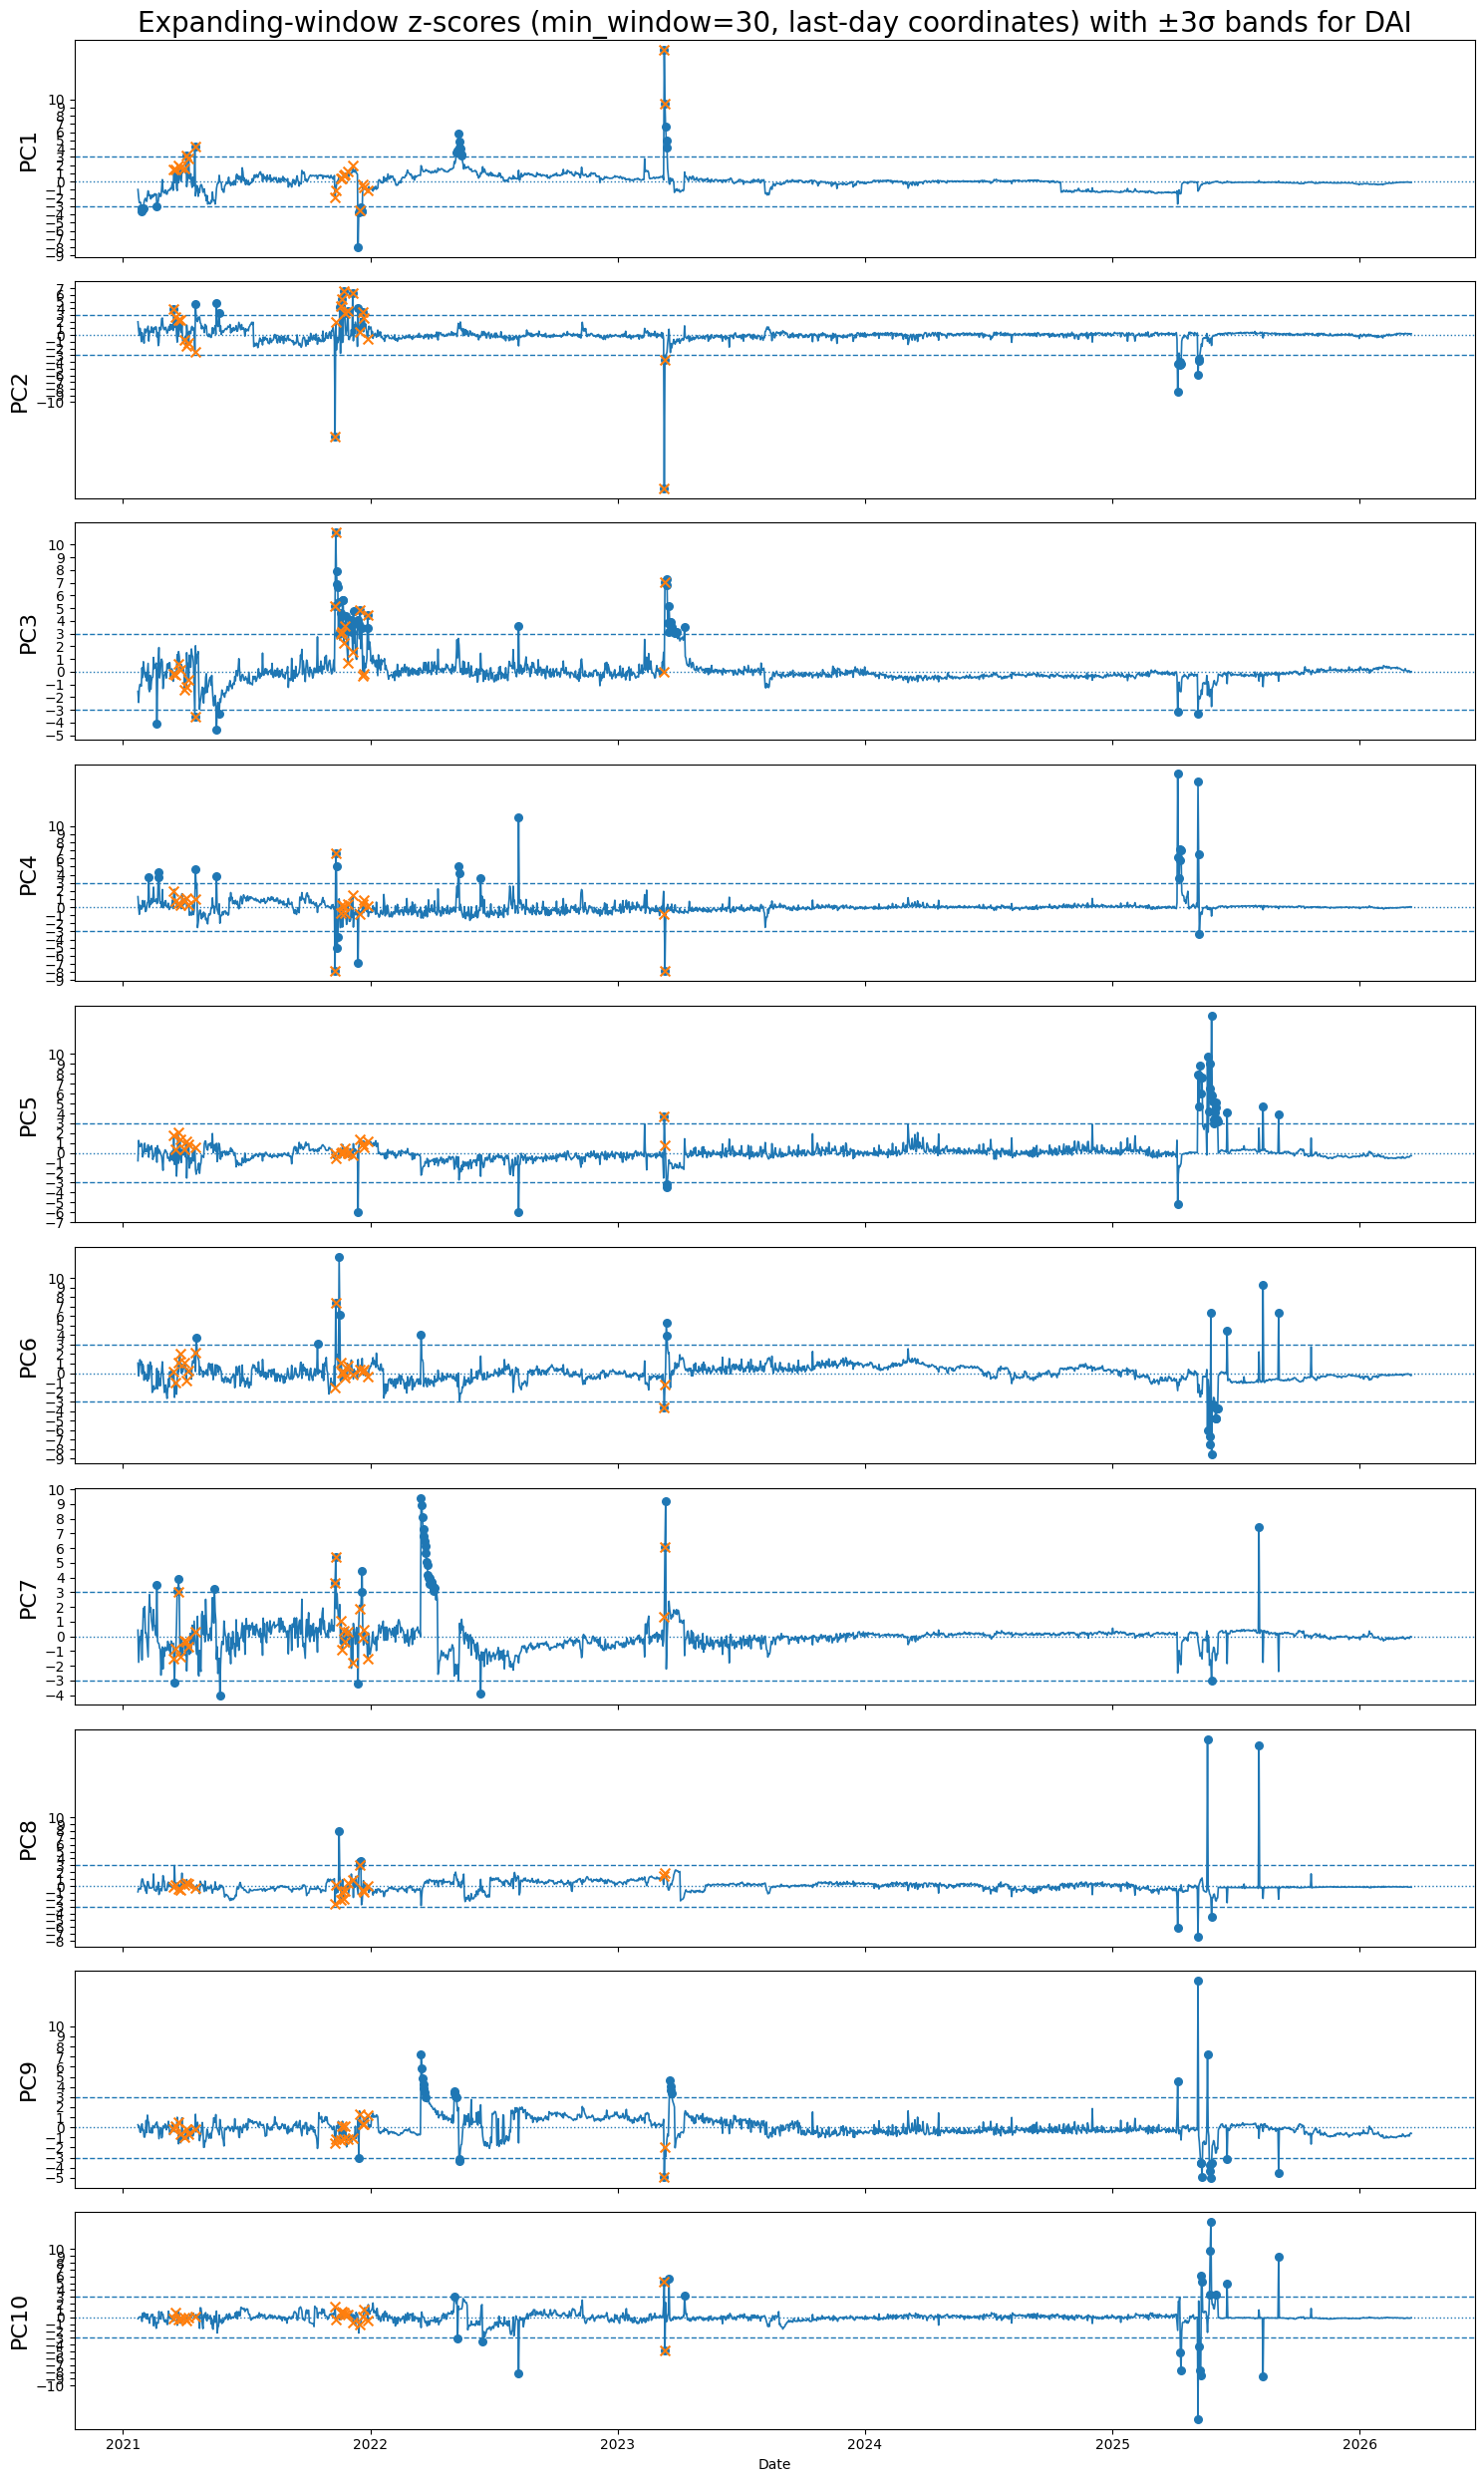

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC3,52,23,19,"[2021-11-19 00:00:00, 2021-11-23 00:00:00, 202...","[2021-11-12 00:00:00, 2021-11-21 00:00:00, 202...",0.999284,4.000000,0.365385,0.593750,0.452381,0.982133
1,PC1,28,23,6,"[2021-12-17 00:00:00, 2021-12-21 00:00:00]","[2021-12-14 00:00:00, 2021-12-18 00:00:00]",0.999194,3.000000,0.214286,0.250000,0.230769,0.988153
2,PC7,37,23,6,"[2021-03-20 00:00:00, 2021-03-23 00:00:00, 202...","[2021-03-18 00:00:00, 2021-03-22 00:00:00, 202...",0.999526,2.000000,0.162162,0.272727,0.203390,0.983288
3,PC4,25,23,4,"[2021-11-19 00:00:00, 2021-12-17 00:00:00]","[2021-11-12 00:00:00, 2021-12-14 00:00:00]",0.999809,5.000000,0.160000,0.181818,0.170213,0.988691
4,PC8,9,23,3,"[2021-11-19 00:00:00, 2021-12-17 00:00:00, 202...","[2021-11-16 00:00:00, 2021-12-16 00:00:00, 202...",0.999568,2.333333,0.333333,0.150000,0.206897,0.996767
5,PC2,24,23,2,"[2021-11-19 00:00:00, 2021-12-17 00:00:00]","[2021-11-17 00:00:00, 2021-12-14 00:00:00]",1.000311,2.500000,0.083333,0.181818,0.114286,0.988216
6,PC6,24,23,2,[2021-11-19 00:00:00],[2021-11-16 00:00:00],0.999143,3.000000,0.083333,0.100000,0.090909,0.988159
7,PC5,31,23,1,[2021-12-17 00:00:00],[2021-12-14 00:00:00],0.999035,3.000000,0.032258,0.047619,0.038462,0.983854
8,PC9,31,23,1,[2021-12-17 00:00:00],[2021-12-15 00:00:00],0.998696,2.000000,0.032258,0.047619,0.038462,0.983854
9,PC10,23,23,0,[],[],0.998444,NaN,0.000000,0.000000,NaN,0.987634


In [13]:
df_dai_final = pd.read_parquet("../clean_data/dai_final.parquet")
df_dai_pca = prepare_stablecoin_pca_df(df_dai_final)
df_dai_pca.columns

pc_scores_dai, loadings_dict_dai = expanding_pca_scores(df=df_dai_pca)

# wanrings and hits
z_df_dai = plot_pc_zscore_bands(pc_scores_dai, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)])[0]

depeg_df_dai = get_real_depeg_days(df_dai_final)
hit_df_dai = get_pc_hits(
    z_df=z_df_dai,
    m=3,
    original_df=df_dai_final,
    depeg_df=depeg_df_dai,
    include_no_lead_time=True
)

# Compare warnings with actual depeg days
plot_dai = plot_pc_zscore_bands(
    z_df_dai,
    m = 3,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_dai,
    depeg_df=depeg_df_dai,
    plot_pc=True
)[1]

summary_df_dai = summarize_pc_hits(
    hit_df=hit_df_dai,
    z_df=z_df_dai,
    depeg_df=depeg_df_dai,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)
summary_df_dai.head(10)

# For PAX

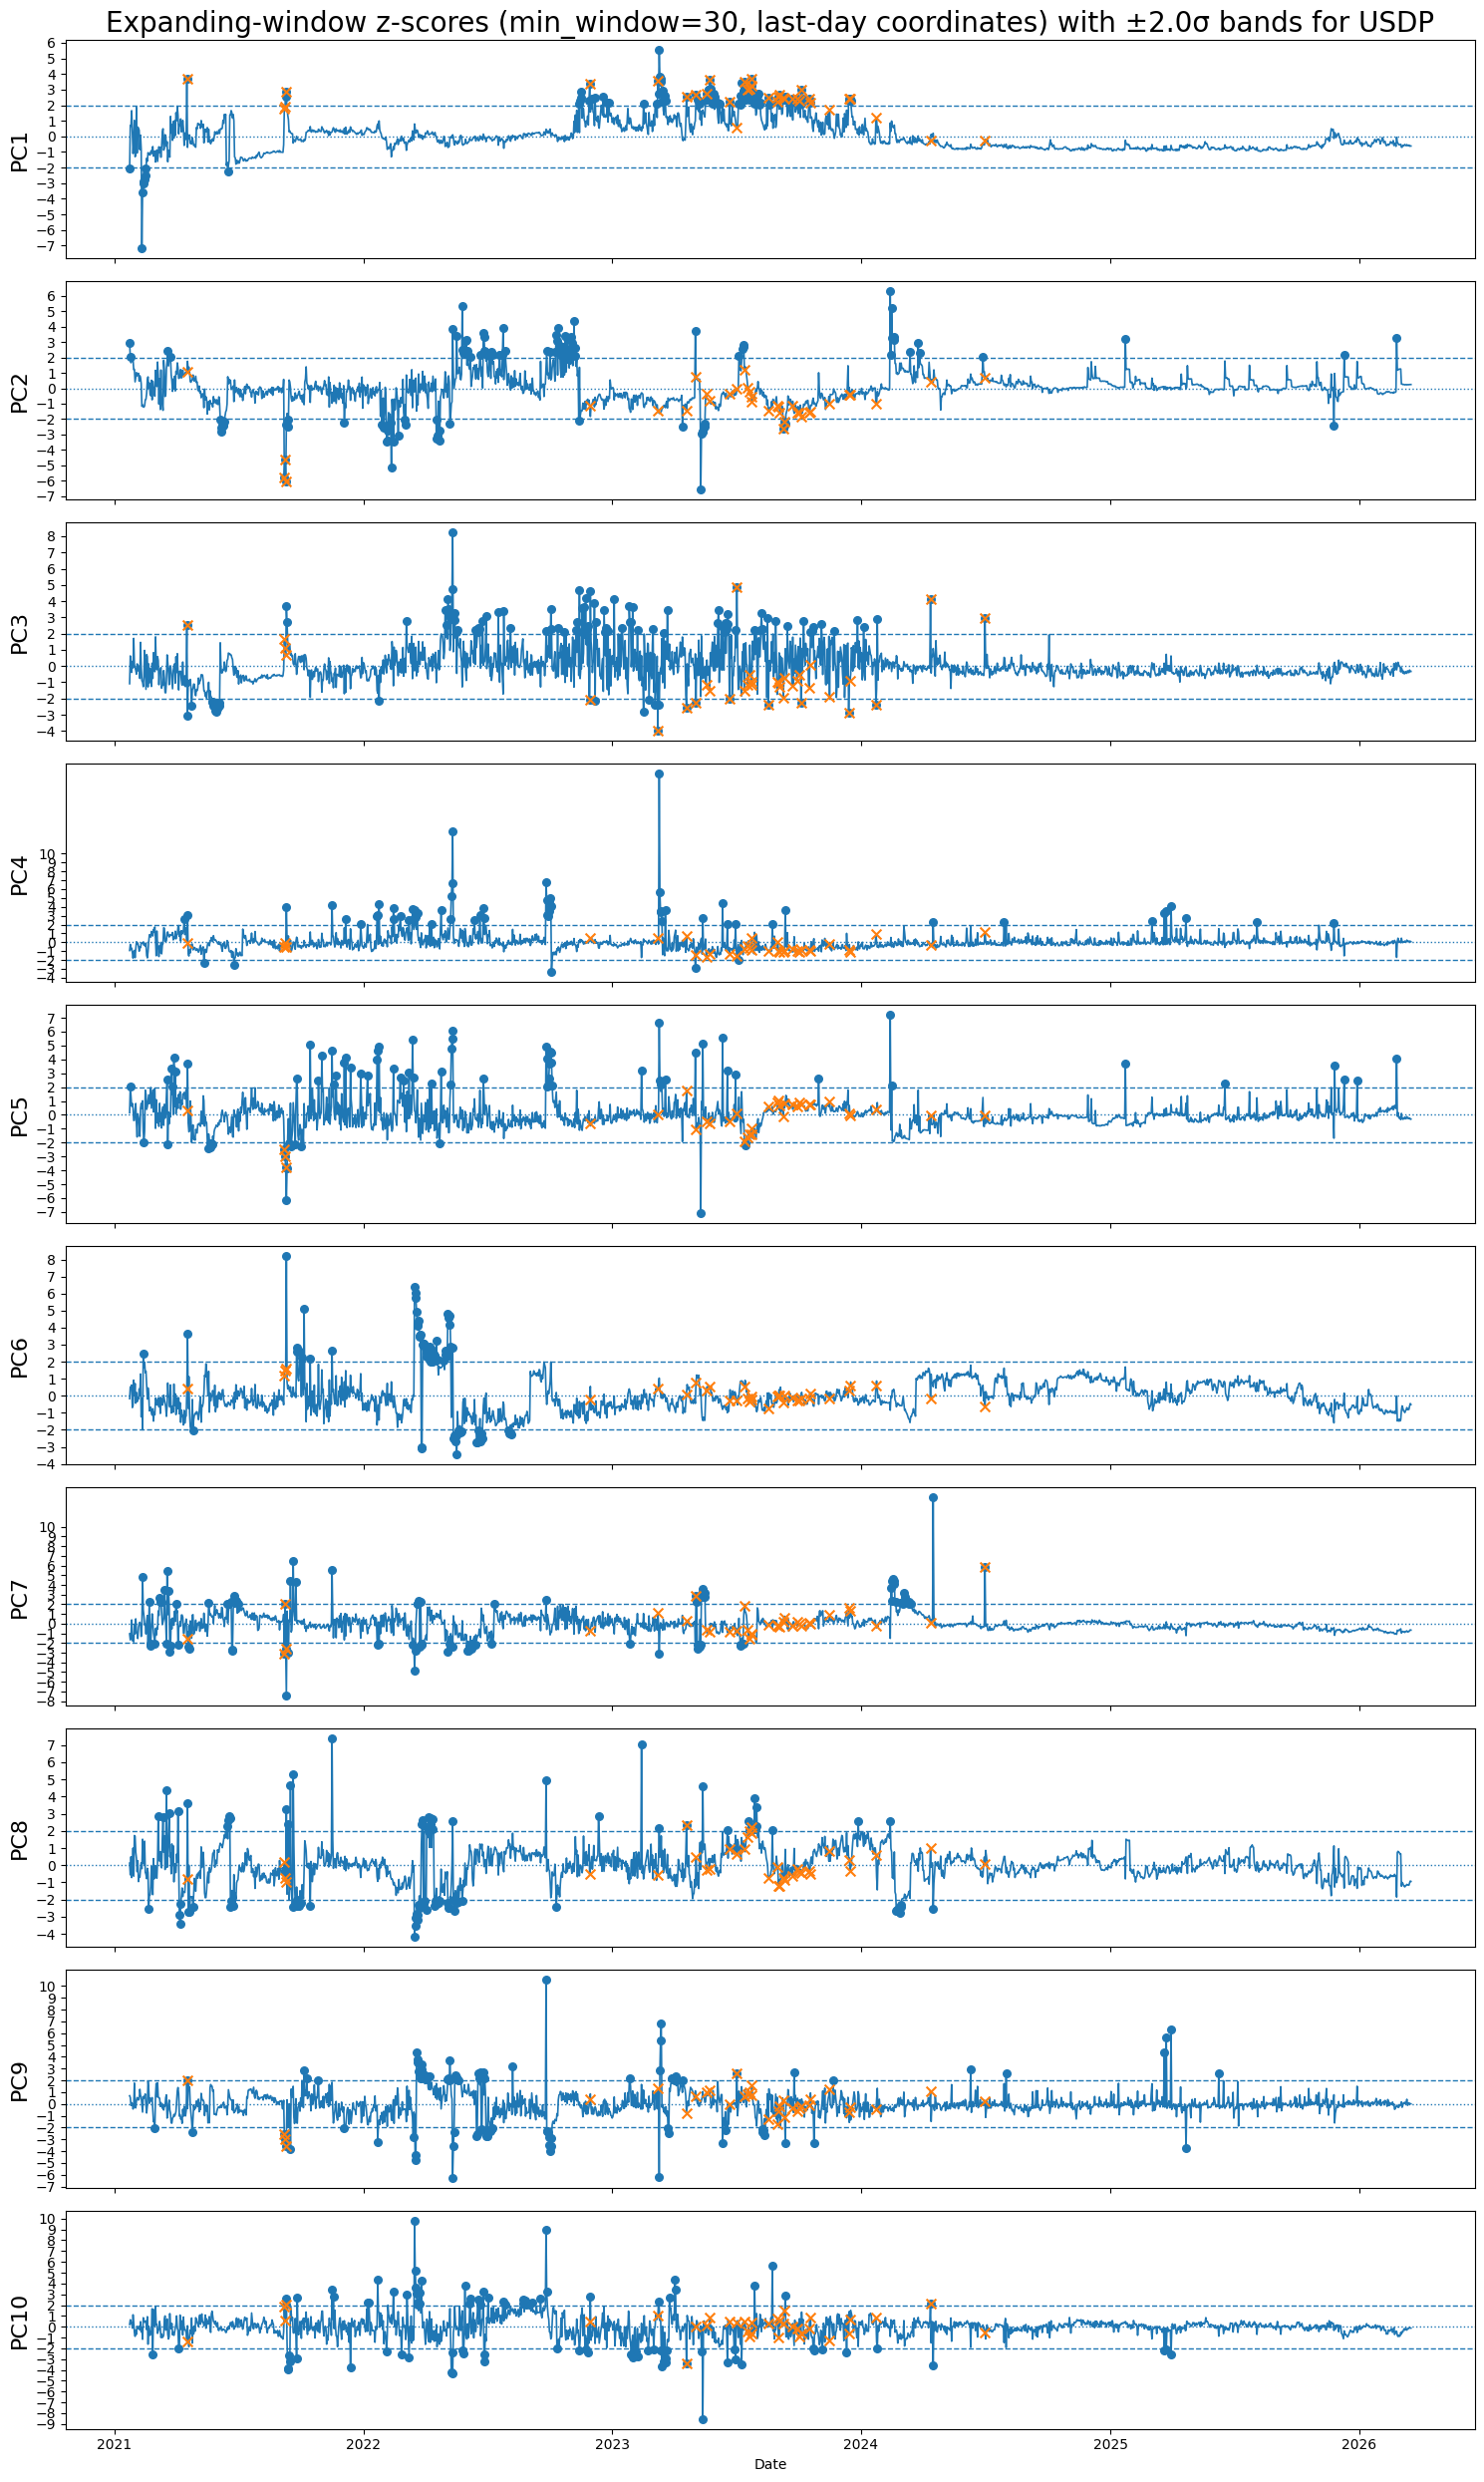

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC1,112,35,27,"[2022-11-29 00:00:00, 2023-03-09 00:00:00, 202...","[2022-11-28 00:00:00, 2023-03-07 00:00:00, 202...",0.994866,2.833333,0.241071,0.627907,0.348387,0.953954
1,PC3,113,35,14,"[2022-11-29 00:00:00, 2023-03-09 00:00:00, 202...","[2022-11-23 00:00:00, 2023-03-02 00:00:00, 202...",1.001409,4.714286,0.123894,0.358974,0.184211,0.946312
2,PC2,113,35,12,"[2023-04-20 00:00:00, 2023-05-04 00:00:00, 202...","[2023-04-14 00:00:00, 2023-05-03 00:00:00, 202...",0.997603,4.000000,0.106195,0.324324,0.160000,0.945049
3,PC10,96,35,10,"[2022-11-29 00:00:00, 2023-03-09 00:00:00, 202...","[2022-11-24 00:00:00, 2023-03-03 00:00:00, 202...",0.999495,4.571429,0.104167,0.270270,0.150376,0.953210
4,PC7,102,35,9,"[2023-05-19 00:00:00, 2023-07-14 00:00:00]","[2023-05-12 00:00:00, 2023-07-08 00:00:00]",0.999657,6.500000,0.088235,0.236842,0.128571,0.949484
5,PC5,84,35,6,"[2023-05-04 00:00:00, 2023-05-19 00:00:00, 202...","[2023-05-03 00:00:00, 2023-05-14 00:00:00, 202...",0.999492,3.000000,0.071429,0.181818,0.102564,0.957655
6,PC4,62,35,5,"[2021-04-17 00:00:00, 2023-05-04 00:00:00, 202...","[2021-04-13 00:00:00, 2023-05-03 00:00:00, 202...",0.999757,3.000000,0.080645,0.142857,0.103093,0.969022
7,PC8,99,35,5,"[2023-05-19 00:00:00, 2023-06-22 00:00:00, 202...","[2023-05-14 00:00:00, 2023-06-19 00:00:00, 202...",0.999888,2.750000,0.050505,0.142857,0.074627,0.948996
8,PC9,99,35,5,"[2023-04-20 00:00:00, 2023-06-22 00:00:00, 202...","[2023-04-15 00:00:00, 2023-06-17 00:00:00, 202...",0.999974,5.250000,0.050505,0.151515,0.075758,0.949051
9,PC6,76,35,0,[],[],1.000945,NaN,0.000000,0.000000,NaN,0.958808


In [14]:
df_pax_final = pd.read_parquet("../clean_data/pax_final.parquet")

df_pax_pca = prepare_stablecoin_pca_df(df_pax_final)

pc_scores_pax, loadings_dict_pax = expanding_pca_scores(df=df_pax_pca)

# wanrings and hits
z_df_pax = plot_pc_zscore_bands(pc_scores_pax, baseline_end="2026-03-19", m = 2.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)])[0]

depeg_df_pax = get_real_depeg_days(df_pax_final)
hit_df_pax = get_pc_hits(
    z_df=z_df_pax,
    m=2,
    original_df=df_pax_final,
    depeg_df=depeg_df_pax,
    include_no_lead_time=True
)

# Compare warnings with actual depeg days
plot_pax = plot_pc_zscore_bands(
    z_df_pax,
    m = 2.0,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_pax,
    depeg_df=depeg_df_pax,
    plot_pc=True
)[1]

summary_df_pax = summarize_pc_hits(
    hit_df=hit_df_pax,
    z_df=z_df_pax,
    depeg_df=depeg_df_pax,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)

summary_df_pax.head(10)

# For USDC

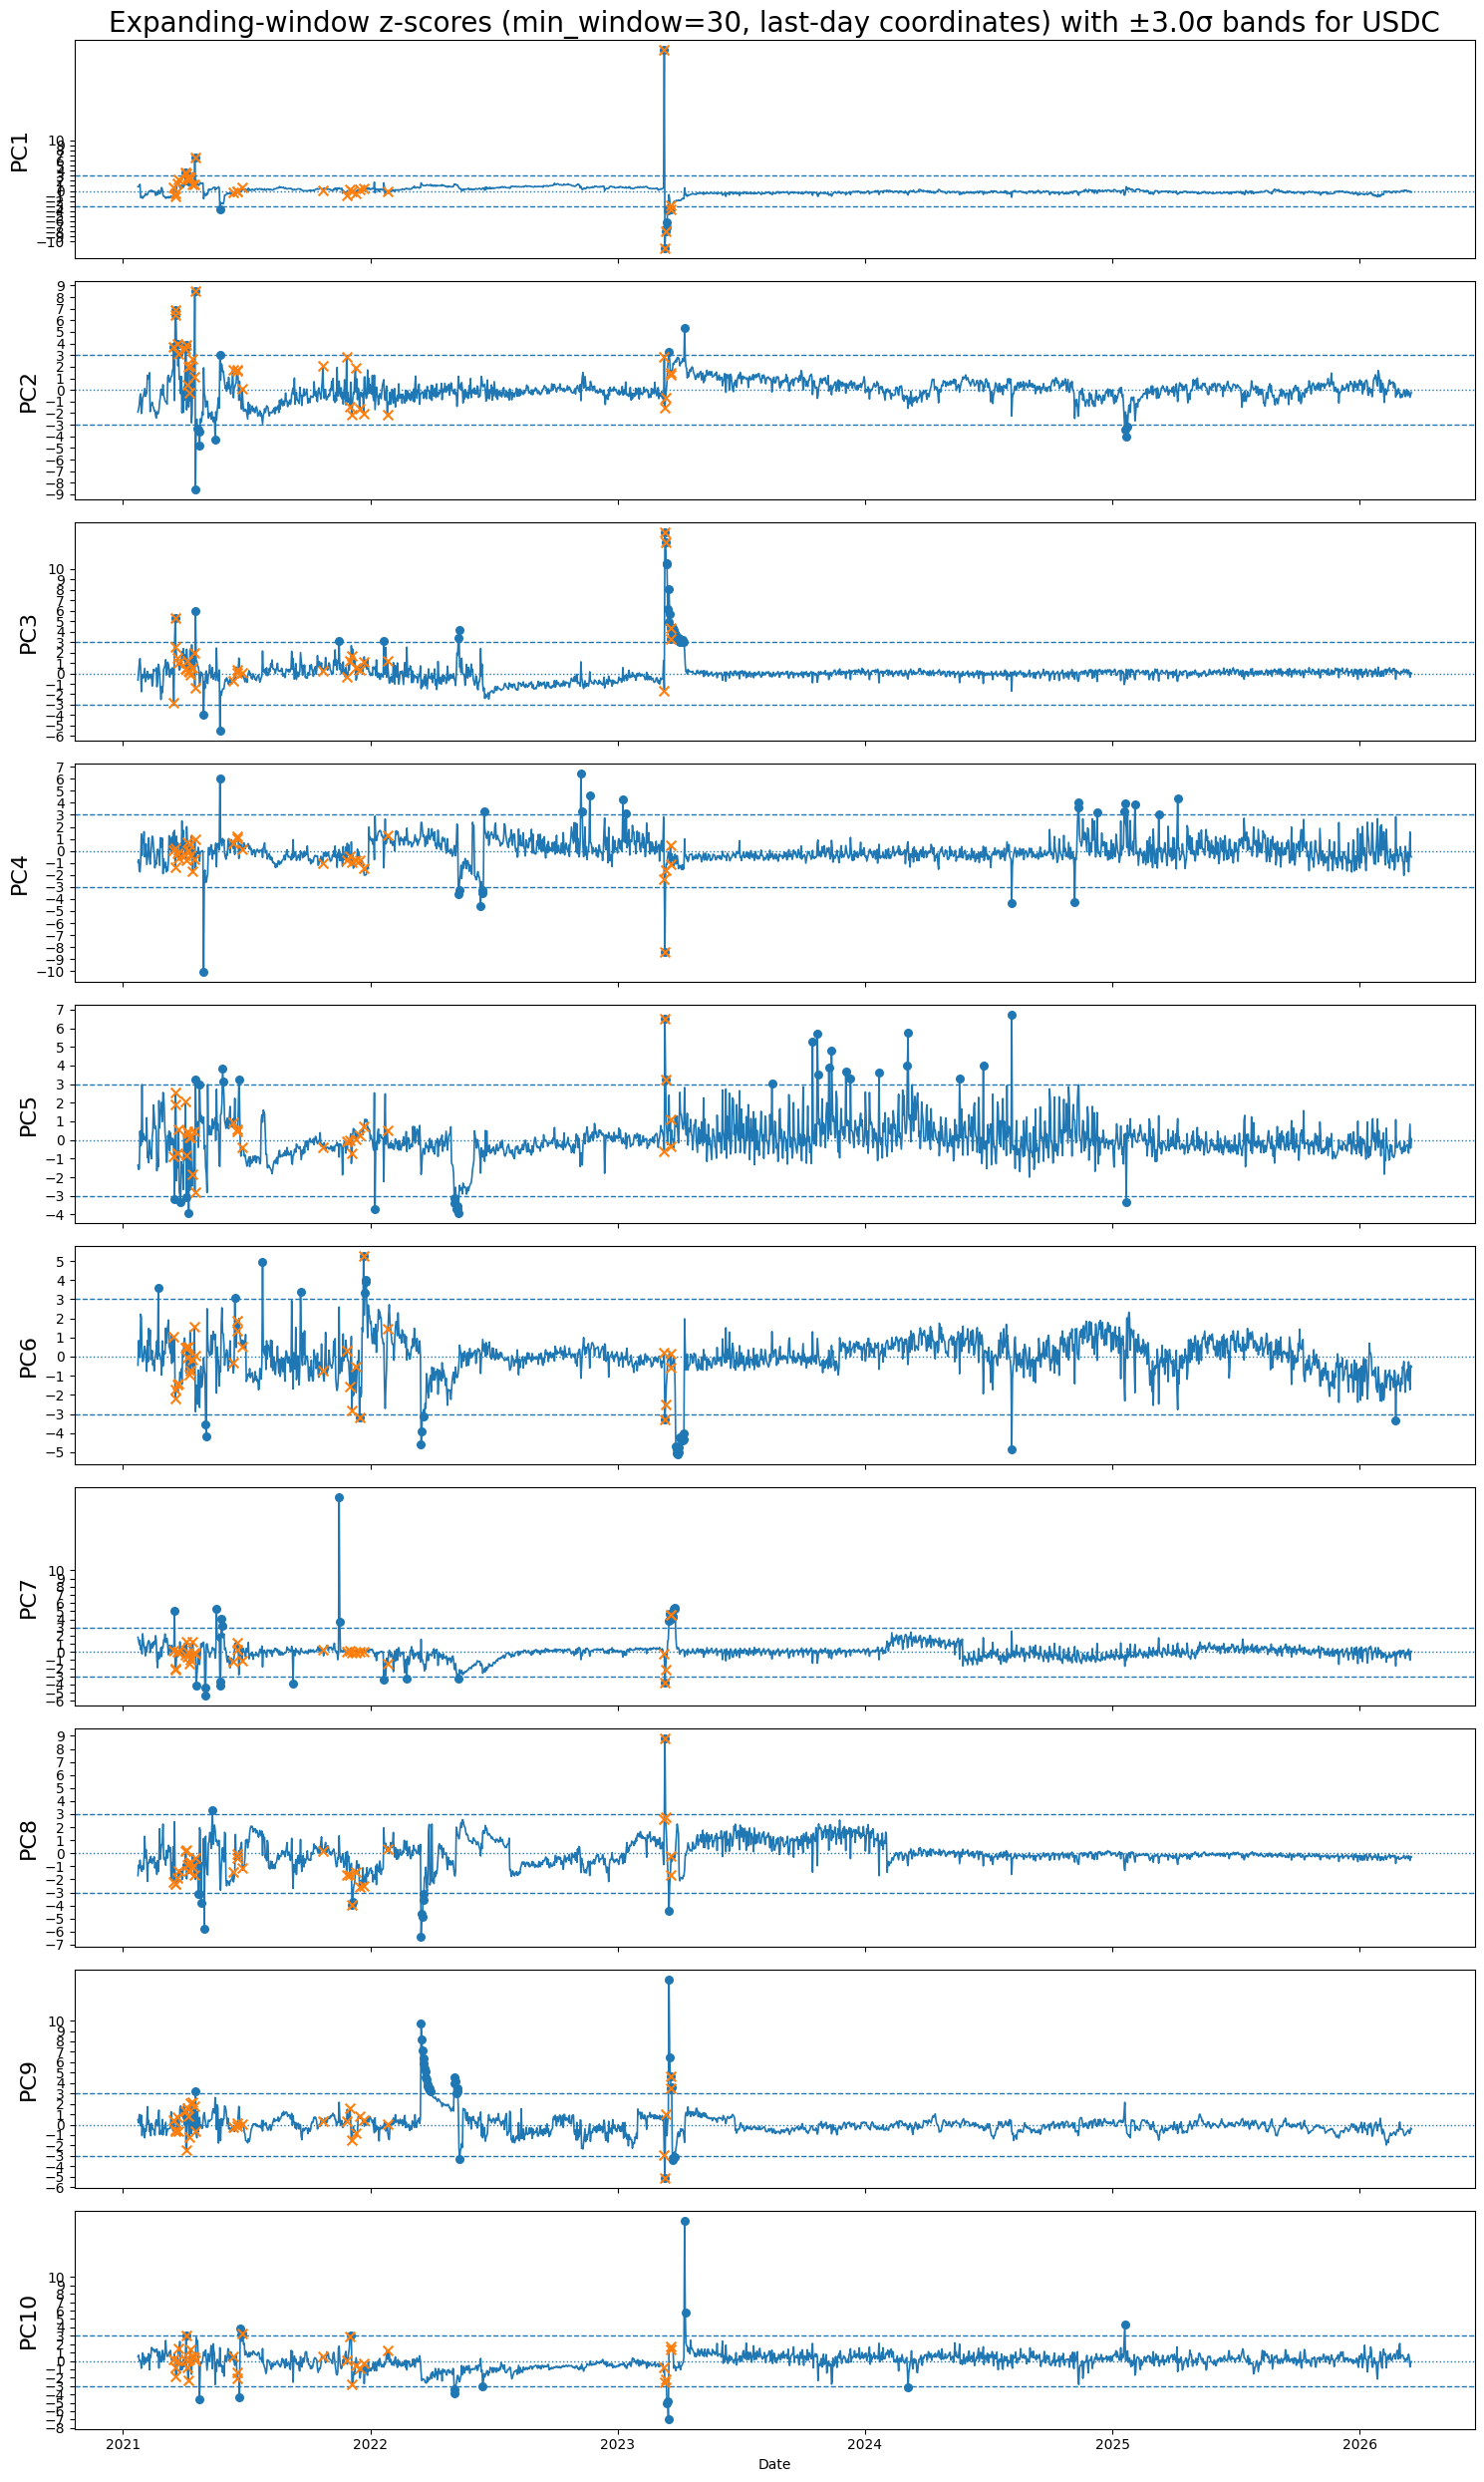

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC10,17,32,7,"[2021-06-26 00:00:00, 2021-12-05 00:00:00, 202...","[2021-06-22 00:00:00, 2021-12-03 00:00:00, 202...",1.000413,3.666667,0.411765,0.233333,0.297872,0.994577
1,PC3,36,32,7,"[2022-01-26 00:00:00, 2023-03-20 00:00:00]","[2022-01-21 00:00:00, 2023-03-14 00:00:00]",0.999634,5.500000,0.194444,0.218750,0.205882,0.984299
2,PC5,33,32,5,"[2021-03-19 00:00:00, 2021-04-03 00:00:00, 202...","[2021-03-18 00:00:00, 2021-03-27 00:00:00, 202...",0.999799,3.000000,0.151515,0.208333,0.175439,0.984832
3,PC7,26,32,4,"[2021-03-19 00:00:00, 2022-01-26 00:00:00, 202...","[2021-03-18 00:00:00, 2022-01-21 00:00:00, 202...",0.999567,2.666667,0.153846,0.142857,0.148148,0.988095
4,PC1,11,32,3,[2023-03-20 00:00:00],[2023-03-14 00:00:00],0.997850,6.000000,0.272727,0.115385,0.162162,0.995683
5,PC8,14,32,2,"[2021-12-10 00:00:00, 2023-03-20 00:00:00]","[2021-12-06 00:00:00, 2023-03-18 00:00:00]",0.999209,3.000000,0.142857,0.066667,0.090909,0.993510
6,PC2,21,32,2,"[2021-03-22 00:00:00, 2023-03-20 00:00:00]","[2021-03-21 00:00:00, 2023-03-18 00:00:00]",1.001135,1.500000,0.095238,0.086957,0.090909,0.989757
7,PC9,32,32,2,[2023-03-20 00:00:00],[2023-03-18 00:00:00],0.999447,2.000000,0.062500,0.064516,0.063492,0.983784
8,PC6,30,32,1,[2021-06-18 00:00:00],[2021-06-15 00:00:00],0.999589,3.000000,0.033333,0.034483,0.033898,0.984333
9,PC4,24,32,0,[],[],0.999880,NaN,0.000000,0.000000,NaN,0.987027


In [15]:
df_usdc_final = pd.read_parquet("../clean_data/usdc_final.parquet")

df_usdc_pca = prepare_stablecoin_pca_df(df_usdc_final)

pc_scores_usdc, loadings_dict_usdc = expanding_pca_scores(df=df_usdc_pca, plot_pc=False)

# wanrings and hits
z_df_usdc = plot_pc_zscore_bands(pc_scores_usdc, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)], plot_pc=False)[0]

depeg_df_usdc = get_real_depeg_days(df_usdc_final)
hit_df_usdc = get_pc_hits(
    z_df=z_df_usdc,
    m=3,
    original_df=df_usdc_final,
    depeg_df=depeg_df_usdc,
    include_no_lead_time=True
)

# Compare warnings with actual depeg days
plot_usdc = plot_pc_zscore_bands(
    z_df_usdc,
    m = 3.0,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_usdc,
    depeg_df=depeg_df_usdc,
    plot_pc=True
)[1]

summary_df_usdc = summarize_pc_hits(
    hit_df=hit_df_usdc,
    z_df=z_df_usdc,
    depeg_df=depeg_df_usdc,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)

summary_df_usdc.head(10)

# For USDT

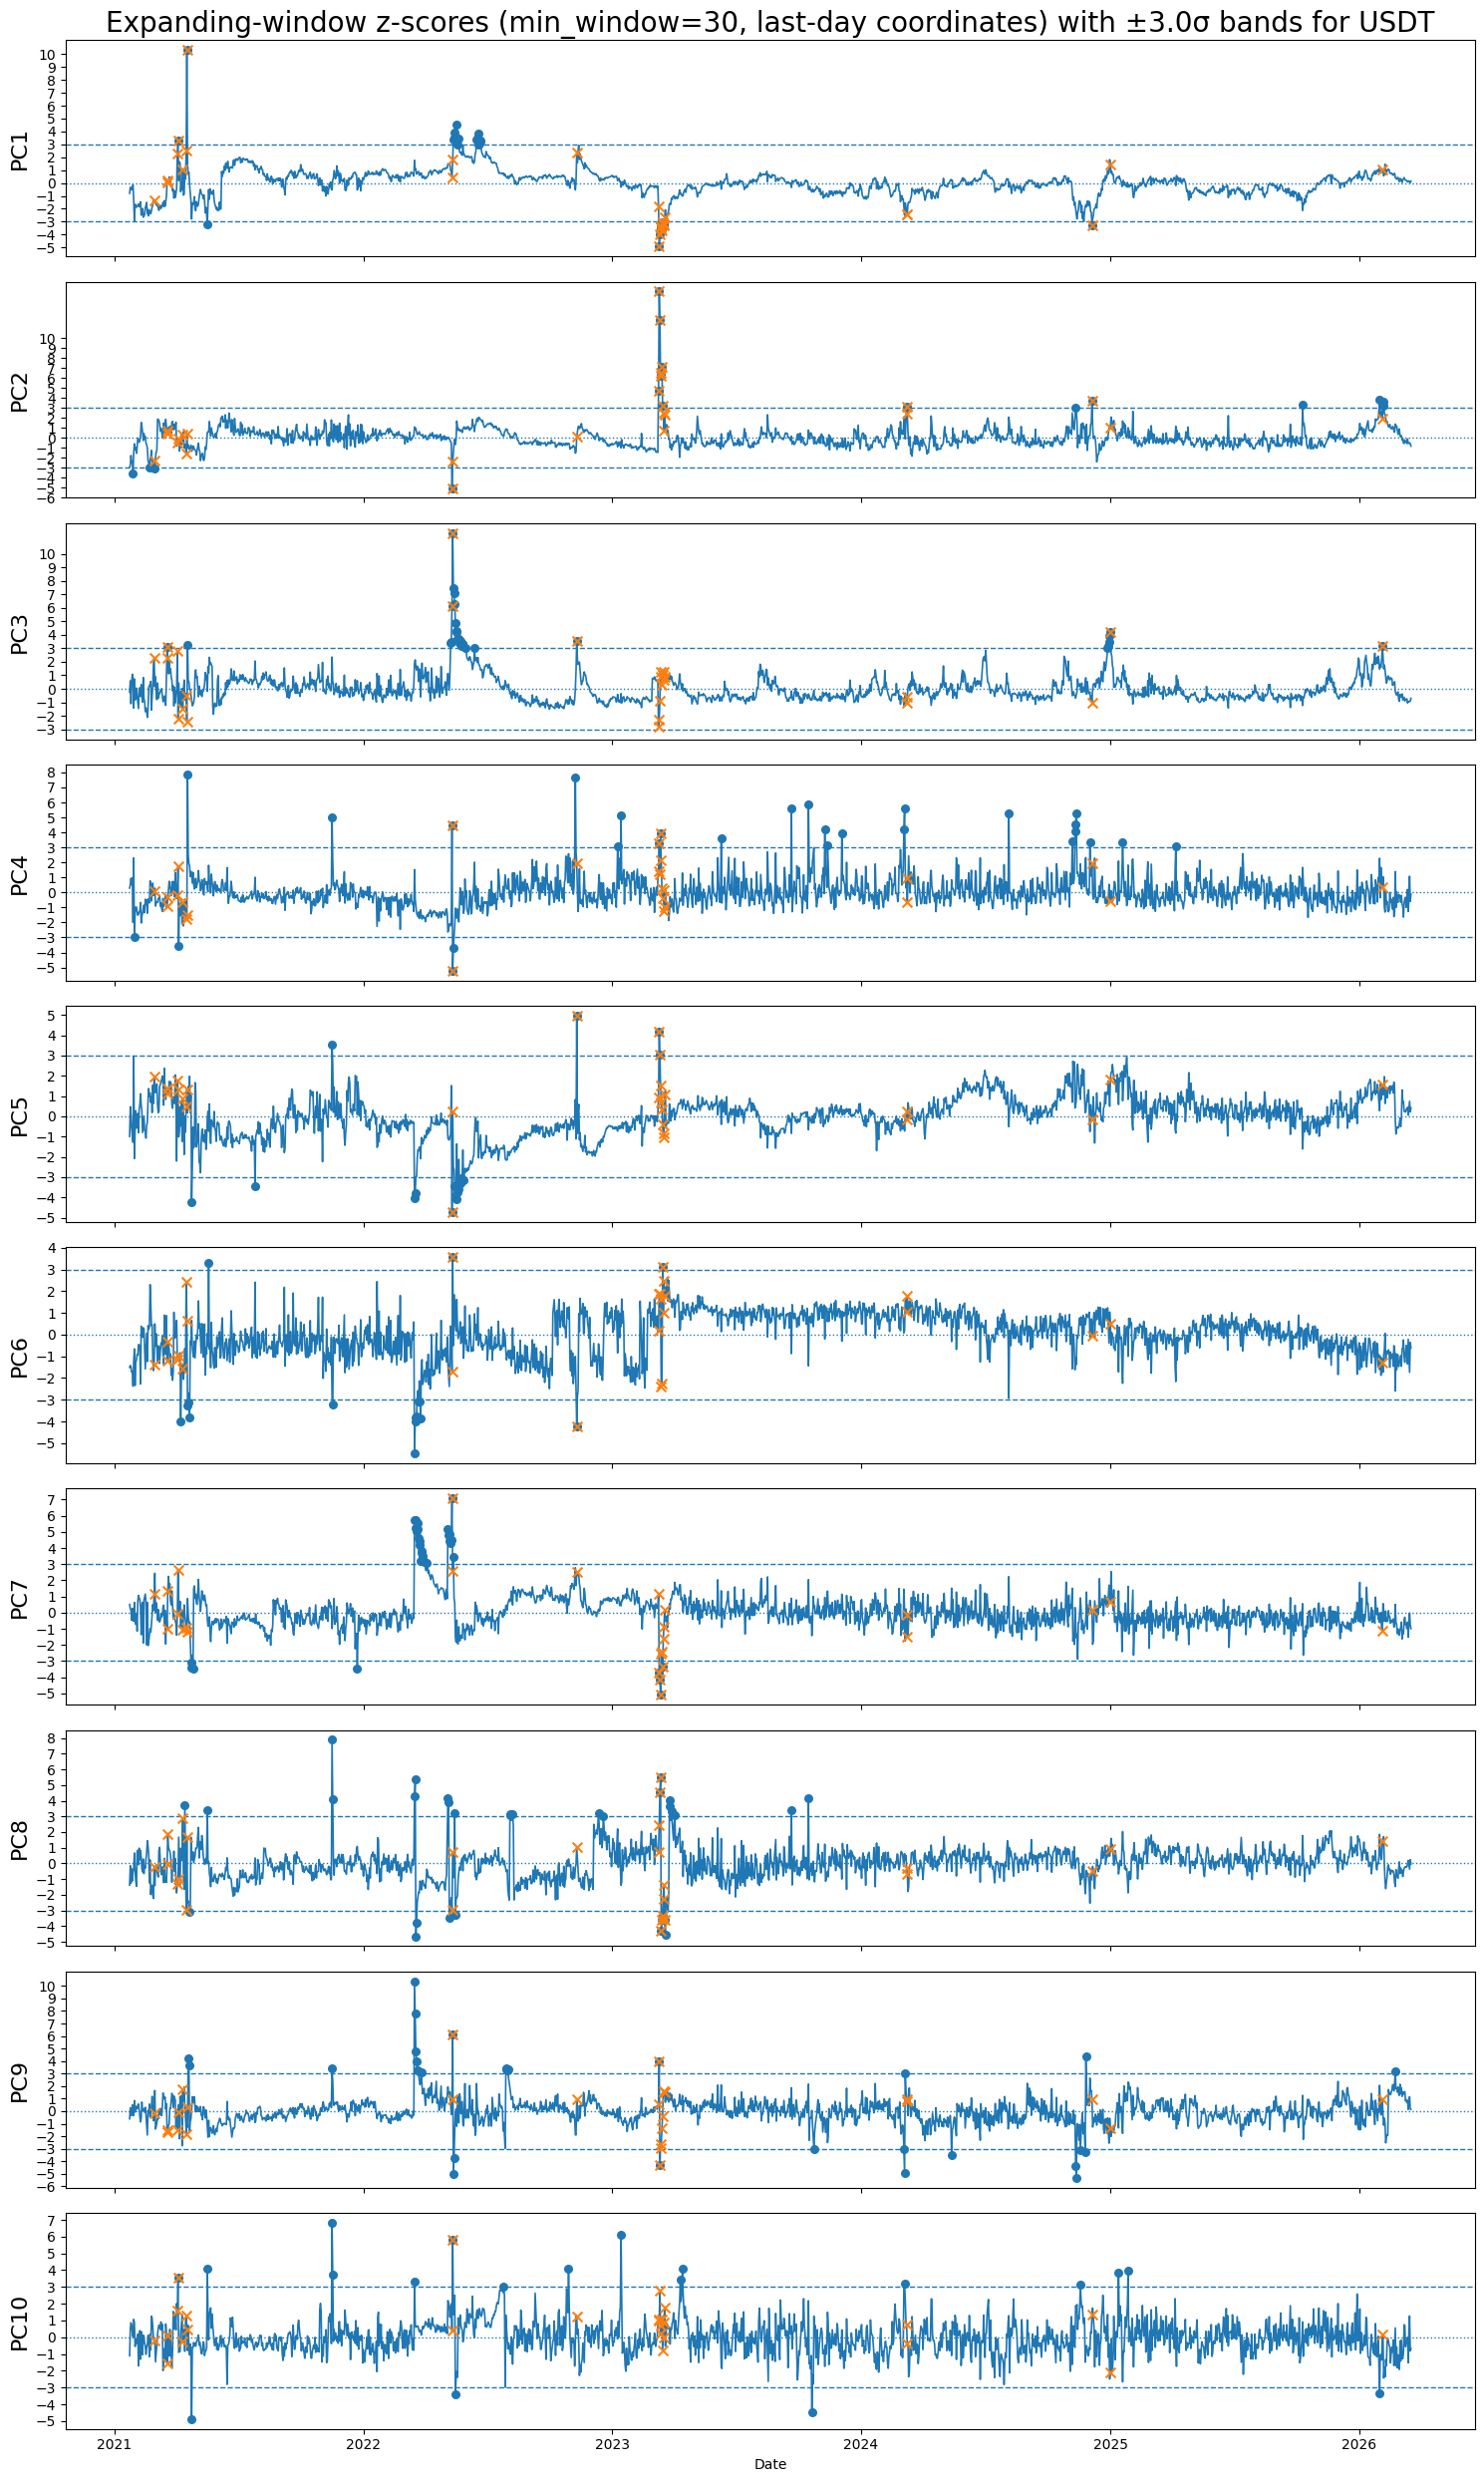

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC3,30,28,6,"[2022-05-11 00:00:00, 2025-01-01 00:00:00]","[2022-05-09 00:00:00, 2024-12-28 00:00:00]",0.998772,3.00,0.200000,0.200000,0.200000,0.987055
1,PC7,32,28,6,[2022-05-11 00:00:00],[2022-05-05 00:00:00],1.000668,6.00,0.187500,0.250000,0.214286,0.985969
2,PC4,28,28,5,"[2021-04-11 00:00:00, 2022-11-10 00:00:00, 202...","[2021-04-05 00:00:00, 2022-11-08 00:00:00, 202...",1.000458,3.75,0.178571,0.263158,0.212766,0.987588
3,PC8,32,28,4,"[2021-04-16 00:00:00, 2022-05-11 00:00:00]","[2021-04-14 00:00:00, 2022-05-05 00:00:00]",1.000912,4.00,0.125000,0.190476,0.150943,0.984914
4,PC9,29,28,3,[2024-03-08 00:00:00],[2024-03-04 00:00:00],1.000644,4.00,0.103448,0.142857,0.120000,0.985976
5,PC2,18,28,2,"[2021-02-28 00:00:00, 2026-02-04 00:00:00]","[2021-02-21 00:00:00, 2026-01-31 00:00:00]",1.001832,5.50,0.111111,0.117647,0.114286,0.991407
6,PC10,19,28,2,"[2024-03-08 00:00:00, 2026-02-04 00:00:00]","[2024-03-05 00:00:00, 2026-01-31 00:00:00]",1.000188,3.50,0.105263,0.076923,0.088889,0.990831
7,PC6,16,28,1,[2021-04-11 00:00:00],[2021-04-08 00:00:00],1.000151,3.00,0.062500,0.040000,0.048780,0.991918
8,PC1,25,28,0,[],[],1.001402,NaN,0.000000,0.000000,NaN,0.986595
9,PC5,19,28,0,[],[],1.000008,NaN,0.000000,0.000000,NaN,0.989774


In [16]:
df_usdt_final = pd.read_parquet("../clean_data/usdt_final.parquet")

df_usdt_pca = prepare_stablecoin_pca_df(df_usdt_final)

pc_scores_usdt, loadings_dict_usdt = expanding_pca_scores(df=df_usdt_pca, plot_pc=False)

# wanrings and hits
z_df_usdt = plot_pc_zscore_bands(pc_scores_usdt, baseline_end="2026-03-19", m = 3.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)], plot_pc=False)[0]

depeg_df_usdt = get_real_depeg_days(df_usdt_final)
hit_df_usdt = get_pc_hits(
    z_df=z_df_usdt,
    m=3,
    original_df=df_usdt_final,
    depeg_df=depeg_df_usdt,
    include_no_lead_time=True
)

# Compare warnings with actual depeg days
plot_usdt = plot_pc_zscore_bands(
    z_df_usdt,
    m = 3.0,
    baseline_end="2026-03-19",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_usdt,
    depeg_df=depeg_df_usdt,
    plot_pc=True
)[1]

summary_df_usdt = summarize_pc_hits(
    hit_df=hit_df_usdt,
    z_df=z_df_usdt,
    depeg_df=depeg_df_usdt,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)

summary_df_usdt.head(10)

# For UST

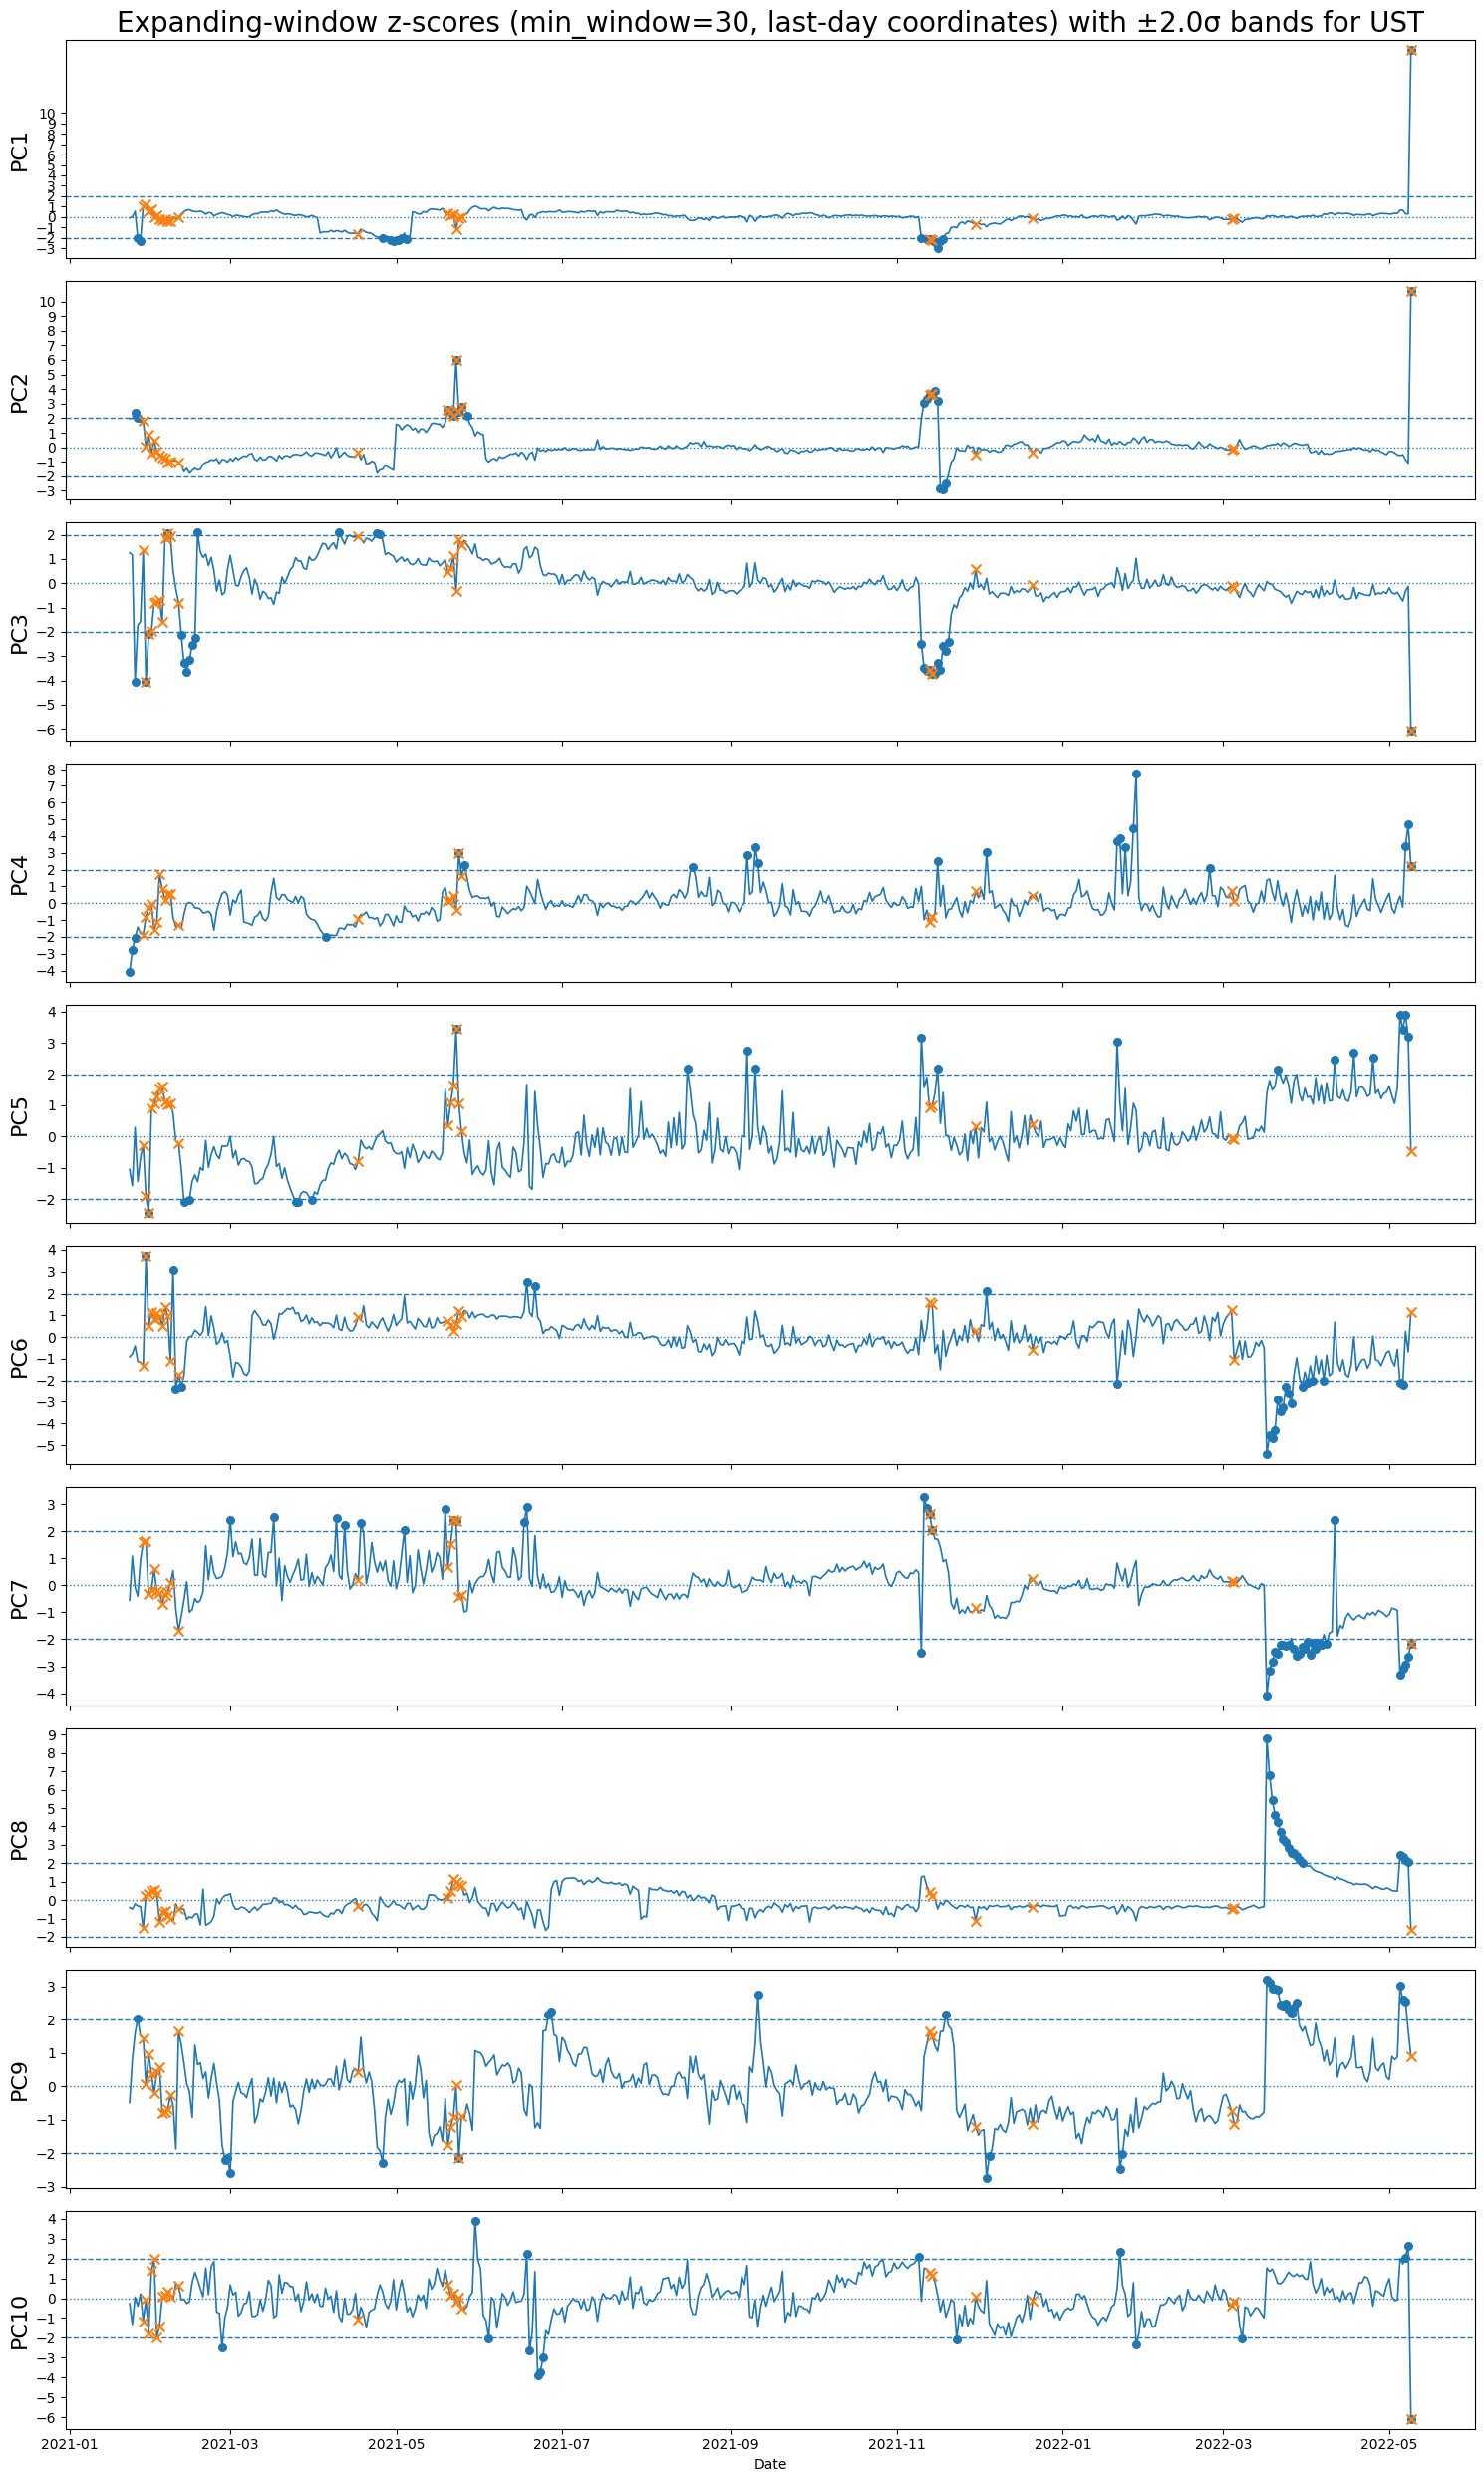

,PC,num_hit_days,num_real_depeg_days,num_matched_days,matched_depeg_days,first_match_days,avg_close_price_hit_days,avg_lead_time_matched,precision,recall,f1_score,specificity
0,PC7,43,32,9,"[2021-04-17 00:00:00, 2021-05-20 00:00:00, 202...","[2021-04-12 00:00:00, 2021-05-19 00:00:00, 202...",0.994225,3.250000,0.209302,0.290323,0.243243,0.923077
1,PC4,21,32,5,"[2021-01-28 00:00:00, 2022-05-09 00:00:00]","[2021-01-23 00:00:00, 2022-05-07 00:00:00]",0.989347,3.500000,0.238095,0.166667,0.196078,0.963883
2,PC5,21,32,5,"[2021-11-13 00:00:00, 2022-05-09 00:00:00]","[2021-11-10 00:00:00, 2022-05-05 00:00:00]",0.999943,3.500000,0.238095,0.200000,0.217391,0.963883
3,PC3,26,32,5,"[2021-01-28 00:00:00, 2021-04-17 00:00:00, 202...","[2021-01-25 00:00:00, 2021-04-10 00:00:00, 202...",0.996334,4.333333,0.192308,0.227273,0.208333,0.953020
4,PC10,16,32,4,"[2021-11-13 00:00:00, 2021-11-30 00:00:00, 202...","[2021-11-09 00:00:00, 2021-11-23 00:00:00, 202...",0.986678,4.333333,0.250000,0.125000,0.166667,0.972912
5,PC1,18,32,4,"[2021-01-28 00:00:00, 2021-11-13 00:00:00]","[2021-01-26 00:00:00, 2021-11-10 00:00:00]",0.990570,2.500000,0.222222,0.148148,0.177778,0.968539
6,PC8,18,32,4,[2022-05-09 00:00:00],[2022-05-05 00:00:00],1.000744,4.000000,0.222222,0.114286,0.150943,0.968326
7,PC2,19,32,4,"[2021-01-28 00:00:00, 2021-11-13 00:00:00]","[2021-01-25 00:00:00, 2021-11-11 00:00:00]",0.984346,2.500000,0.210526,0.173913,0.190476,0.966741
8,PC6,24,32,4,"[2021-02-10 00:00:00, 2022-05-09 00:00:00]","[2021-02-08 00:00:00, 2022-05-05 00:00:00]",1.002355,3.000000,0.166667,0.148148,0.156863,0.954853
9,PC9,29,32,4,"[2021-01-28 00:00:00, 2022-05-09 00:00:00]","[2021-01-26 00:00:00, 2022-05-05 00:00:00]",1.000455,3.000000,0.137931,0.142857,0.140351,0.943567


In [17]:
df_ust_final = pd.read_parquet("../clean_data/ust_final.parquet")
df_ust_final = df_ust_final[df_ust_final["timestamp"] <= "2022-05-10"].reset_index(drop=True)

df_ust_pca = prepare_stablecoin_pca_df(df_ust_final)

pc_scores_ust, loadings_dict_ust = expanding_pca_scores(df=df_ust_pca, plot_pc=False)

# wanrings and hits
z_df_ust = plot_pc_zscore_bands(pc_scores_ust, baseline_end="2022-05-10", m = 2.0,
                     pc_cols=[f"PC{i}" for i in range(1, 11)], plot_pc=False)[0]

depeg_df_ust = get_real_depeg_days(df_ust_final)
hit_df_ust = get_pc_hits(
    z_df=z_df_ust,
    m=2,
    original_df=df_ust_final,
    depeg_df=depeg_df_ust,
    include_no_lead_time=True
)

# Compare warnings with actual depeg days
plot_ust = plot_pc_zscore_bands(
    z_df_ust,
    m = 2.0,
    baseline_end="2022-05-10",
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    hit_df=hit_df_ust,
    depeg_df=depeg_df_ust,
    plot_pc=True
)[1]

summary_df_ust = summarize_pc_hits(
    hit_df=hit_df_ust,
    z_df=z_df_ust,
    depeg_df=depeg_df_ust,
    pc_cols=[f"PC{i}" for i in range(1, 11)],
    max_lead_days=7,
    include_no_lead_time=False
)

summary_df_ust.head(10)

# Summaries
## About hit days

In [18]:
# output all plots
plot_dai.savefig("dai_pc_zscore_bands.png")
plot_pax.savefig("pax_pc_zscore_bands.png")
plot_usdc.savefig("usdc_pc_zscore_bands.png")
plot_usdt.savefig("usdt_pc_zscore_bands.png")
plot_ust.savefig("ust_pc_zscore_bands.png")

In [19]:
# concat all summaries
summary_all = pd.concat([
    summary_df_dai.assign(stablecoin="DAI"),
    summary_df_pax.assign(stablecoin="PAX"),
    summary_df_usdc.assign(stablecoin="USDC"),
    summary_df_usdt.assign(stablecoin="USDT"),
    summary_df_ust.assign(stablecoin="UST")
], ignore_index=True)

summary_all['window'] = 'expanding_30d'

# reorder columns
summary_all = summary_all[[
    'window', 'stablecoin', 'PC', 'num_hit_days', 'num_real_depeg_days', 'num_matched_days',
    'avg_lead_time_matched', 'precision', 'recall', 'f1_score', 'specificity',
    'matched_depeg_days', 'first_match_days', 'avg_close_price_hit_days'
]]

summary_all.to_csv("summary_hit_days_all_expanding_30d.csv", index=False)

In [20]:
# concat all hit details
hit_details_all = pd.concat([
    hit_df_dai.assign(stablecoin="DAI"),
    hit_df_pax.assign(stablecoin="PAX"),
    hit_df_usdc.assign(stablecoin="USDC"),    
    hit_df_usdt.assign(stablecoin="USDT"),
    hit_df_ust.assign(stablecoin="UST")
], ignore_index=True)

# reorder columns
hit_details_all = hit_details_all[[
    "stablecoin", "hit_date", "PC", "z_score", "close_price",
    "matched_depeg_date", "lead_time_days", "is_matched"
]]

hit_details_all.to_csv("detailed_hit_days_all.csv", index=False)

## Matched depeg loadings

In [21]:
# Get the loadings on days when hits match depeg days 
def get_matched_hit_pc_loadings(hit_df, depeg_df, loadings_dict, max_lead_days=7):

    hit_df = hit_df.copy()
    depeg_df = depeg_df.copy()

    hit_df["hit_date"] = pd.to_datetime(hit_df["hit_date"]).dt.normalize()
    depeg_df["timestamp"] = pd.to_datetime(depeg_df["timestamp"]).dt.normalize()

    depeg_dates = sorted(depeg_df["timestamp"].drop_duplicates())

    matched_rows = []

    for _, row in hit_df.iterrows():
        hit_date = row["hit_date"]

        # find depeg dates that occur on or after the hit date,
        # but no more than max_lead_days later
        valid_depegs = [
            d for d in depeg_dates
            if hit_date <= d and (d - hit_date).days <= max_lead_days
        ]

        if len(valid_depegs) > 0:
            nearest_depeg = min(valid_depegs)
            temp = row.copy()
            temp["matched_depeg_date"] = nearest_depeg
            temp["lead_time_days"] = (nearest_depeg - hit_date).days
            matched_rows.append(temp)

    if len(matched_rows) == 0:
        matched_hit_df = pd.DataFrame(columns=list(hit_df.columns) + ["matched_depeg_date", "lead_time_days"])
        matched_pc_loadings_df = pd.DataFrame(columns=[
            "timestamp", "matched_depeg_date", "lead_time_days",
            "PC", "feature", "loading", "abs_loading"
        ])
        return matched_hit_df, matched_pc_loadings_df

    matched_hit_df = pd.DataFrame(matched_rows).sort_values(["hit_date", "PC"]).reset_index(drop=True)

    loading_rows = []

    for _, row in matched_hit_df.iterrows():
        dt = row["hit_date"]
        pc = row["PC"]

        if dt in loadings_dict and pc in loadings_dict[dt].columns:
            temp = loadings_dict[dt][[pc]].copy()
            temp = temp.rename(columns={pc: "loading"})
            temp["abs_loading"] = temp["loading"].abs()
            temp["feature"] = temp.index
            temp["timestamp"] = dt
            temp["matched_depeg_date"] = row["matched_depeg_date"]
            temp["lead_time_days"] = row["lead_time_days"]
            temp["PC"] = pc

            temp = temp.reset_index(drop=True)[[
                "timestamp", "matched_depeg_date", "lead_time_days",
                "PC", "feature", "loading", "abs_loading"
            ]]

            loading_rows.append(temp)

    if len(loading_rows) == 0:
        matched_pc_loadings_df = pd.DataFrame(columns=[
            "timestamp", "matched_depeg_date", "lead_time_days",
            "PC", "feature", "loading", "abs_loading"
        ])
    else:
        matched_pc_loadings_df = pd.concat(loading_rows, ignore_index=True)

    return matched_hit_df, matched_pc_loadings_df

In [22]:
matched_hit_df_dai, matched_pc_loadings_df_dai = get_matched_hit_pc_loadings(
    hit_df=hit_df_dai,
    depeg_df=depeg_df_dai,
    loadings_dict=loadings_dict_dai,
    max_lead_days=7
)
matched_pc_loadings_df_dai.to_csv("matched_depeg_loadings_dai.csv", index=False)

In [23]:
matched_hit_df_pax, matched_pc_loadings_df_pax = get_matched_hit_pc_loadings(
    hit_df=hit_df_pax,
    depeg_df=depeg_df_pax,
    loadings_dict=loadings_dict_pax,
    max_lead_days=7
)
matched_pc_loadings_df_pax.to_csv("matched_depeg_loadings_pax.csv", index=False)

In [24]:
matched_hit_df_usdc, matched_pc_loadings_df_usdc = get_matched_hit_pc_loadings(
    hit_df=hit_df_usdc,
    depeg_df=depeg_df_usdc,
    loadings_dict=loadings_dict_usdc,
    max_lead_days=7
)
matched_pc_loadings_df_usdc.to_csv("matched_depeg_loadings_usdc.csv", index=False)

In [25]:
matched_hit_df_usdt, matched_pc_loadings_df_usdt = get_matched_hit_pc_loadings(
    hit_df=hit_df_usdt,
    depeg_df=depeg_df_usdt,
    loadings_dict=loadings_dict_usdt,
    max_lead_days=7
)
matched_pc_loadings_df_usdt.to_csv("matched_depeg_loadings_usdt.csv", index=False)

In [26]:
matched_hit_df_ust, matched_pc_loadings_df_ust = get_matched_hit_pc_loadings(
    hit_df=hit_df_ust,
    depeg_df=depeg_df_ust,
    loadings_dict=loadings_dict_ust,
    max_lead_days=7
)
matched_pc_loadings_df_ust.to_csv("matched_depeg_loadings_ust.csv", index=False)

## About loadings of each PC

In [27]:
loadings_dict_dai[pd.Timestamp("2022-04-10")]

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
percent_change_24h,-0.048136,0.332215,-0.241787,0.047335,-0.097486,0.230093,0.345531,-0.042051,-0.234660,-0.270932
percent_change_7d,-0.030530,0.337227,-0.284822,0.065686,-0.093957,0.254195,0.071014,0.042695,0.014237,-0.183508
percent_change_30d,0.040623,0.394642,-0.224359,0.036501,-0.001667,0.008257,-0.029628,-0.066357,0.133636,0.358613
volume_percent_change_24h,0.011261,-0.123471,0.149702,0.407108,-0.206347,0.291128,-0.004743,-0.227436,0.224083,0.422818
volume_percent_change_7d,-0.035568,-0.101553,0.103513,0.448858,-0.294191,0.132627,0.115625,-0.305932,0.060925,0.022447
volume_percent_change_30d,-0.096858,-0.148653,0.083687,0.437908,-0.277302,-0.127487,0.047506,0.026469,-0.261787,-0.421253
market_cap_percent_change_24h,0.270471,0.028029,0.136212,0.309844,0.483665,0.062787,0.174291,0.153778,-0.087018,0.045022
market_cap_percent_change_7d,0.393606,0.147180,0.029104,0.078359,0.004628,-0.118630,-0.329094,-0.193845,0.225512,-0.290382
market_cap_percent_change_30d,0.376382,0.096302,0.090355,-0.056371,-0.333293,-0.166762,0.042910,0.122181,-0.346118,0.189405
circulating_supply_percent_change_24h,0.267486,0.060818,0.113020,0.316549,0.476533,0.086362,0.209170,0.149490,-0.110196,0.017505


In [28]:
loadings_df_dai = loadings_dict_dai[pd.Timestamp("2022-04-10")]
loadings_df_dai["PC1"].abs().sort_values(ascending=False).head(5)

market_cap_percent_change_7d             0.393606
circulating_supply_percent_change_7d     0.391399
circulating_supply_percent_change_30d    0.376480
market_cap_percent_change_30d            0.376382
price_deviation_30d                      0.286941
Name: PC1, dtype: float64

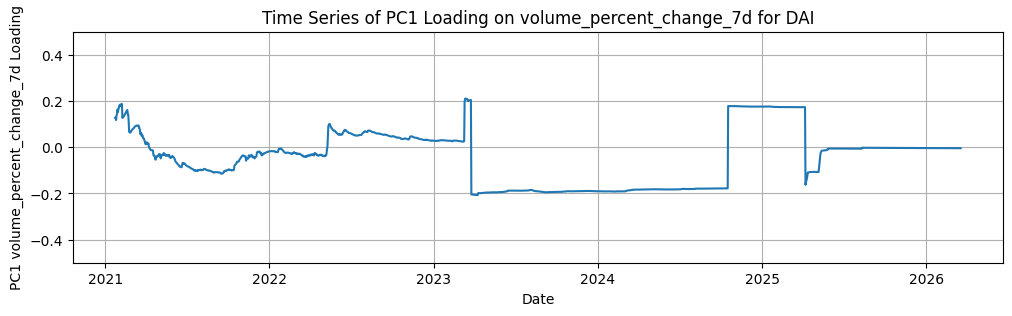

In [29]:
feature = "volume_percent_change_7d"

series = {
    t: df.loc[feature, "PC1"]
    for t, df in loadings_dict_dai.items()
}

series = pd.Series(series).sort_index()

# plot time series of PC1 loading on volume_percent_change_7d
plt.figure(figsize=(12, 3))
plt.plot(series.index, series.values, linestyle="-")
plt.title("Time Series of PC1 Loading on volume_percent_change_7d for DAI")
plt.xlabel("Date")
plt.ylabel("PC1 volume_percent_change_7d Loading")
plt.grid()

# set the y axis limits to be -0.5 to 0.5 for better visualization
plt.ylim(-0.5, 0.5)
plt.show()
